# 01 — Théorie du fluide tachyonique

Ce notebook implémente et valide le modèle de tachyon roulant (Sen 2002)
qui sera ensuite injecté dans cobaya comme fluide d'énergie noire externe.

**Objectif** : vérifier que w(z) reste dans [-1, 0] pour les deux
potentiels candidats (exponentiel, inverse-puissance), et observer
le comportement qualitatif attendu avant de lancer le MCMC.

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import matplotlib.pyplot as plt
from src.tachyon.potentials import ExponentialPotential, InversePowerPotential
from src.tachyon.rolling_tachyon import build_tachyon_background, sanity_checks

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,'axes.grid': True, 'grid.alpha': 0.3})

Omega_m = 0.30

Matplotlib is building the font cache; this may take a moment.


POTENTIEL EXPONENTIEL  V(phi) = V0 * exp(-lambda*phi)

--- lambda = 0.3 ---
SANITY CHECKS
  w_in_range                   : OK
  H_today_is_1                 : OK
  Omega_DE_today_correct       : OK
  phidot_sub_1                 : OK
  w(z=0)                       = -0.9935
  w range observé              = [-1.0000, -0.9935]
  H(z=0)                       = 1.000000
  Omega_DE(z=0)                = 0.7000  (attendu 0.7000)
  max|phi_dot|                 = 0.0807

--- lambda = 0.7 ---
SANITY CHECKS
  w_in_range                   : OK
  H_today_is_1                 : OK
  Omega_DE_today_correct       : OK
  phidot_sub_1                 : OK
  w(z=0)                       = -0.9651
  w range observé              = [-1.0000, -0.9651]
  H(z=0)                       = 1.000000
  Omega_DE(z=0)                = 0.7000  (attendu 0.7000)
  max|phi_dot|                 = 0.1869

--- lambda = 1.2 ---
SANITY CHECKS
  w_in_range                   : OK
  H_today_is_1                 : OK
  Omega_DE_t

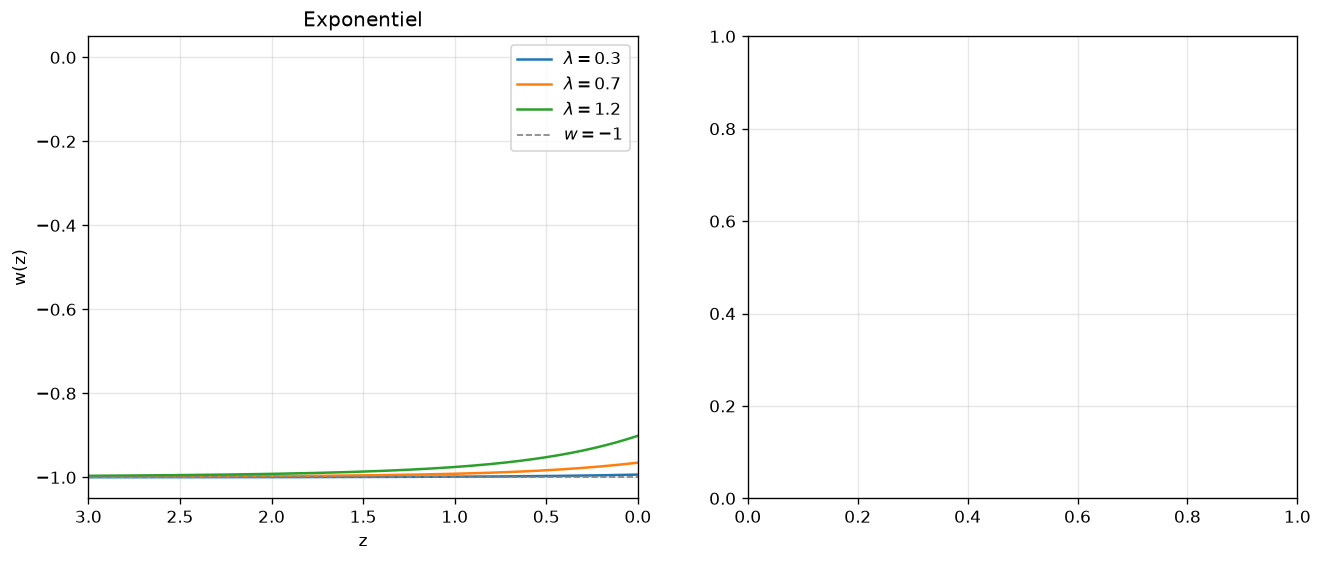

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

print("="*60)
print("POTENTIEL EXPONENTIEL  V(phi) = V0 * exp(-lambda*phi)")
print("="*60)

for lam in [0.3, 0.7, 1.2]:
    pot_template = ExponentialPotential(V0=1.0, lam=lam)
    bg = build_tachyon_background(pot_template, Omega_m,
                                   phi_init=0.0, x_init=0.0, z_init=50.0)
    print(f"\n--- lambda = {lam} ---")
    sanity_checks(bg)
    axes[0].plot(bg["z"], bg["w"], label=fr"$\lambda={lam}$")

axes[0].set_xlim(0, 3); axes[0].set_ylim(-1.05, 0.05)
axes[0].axhline(-1, color='gray', ls='--', lw=1, label=r'$w=-1$')
axes[0].set_xlabel("z"); axes[0].set_ylabel("w(z)")
axes[0].set_title("Exponentiel"); axes[0].invert_xaxis(); axes[0].legend()

In [3]:
print("="*60)
print("POTENTIEL INVERSE-PUISSANCE  V(phi) = V0 * phi^-n")
print("="*60)

for n in [0.5, 1.0, 2.0]:
    pot_template = InversePowerPotential(V0=1.0, n=n)
    bg = build_tachyon_background(pot_template, Omega_m,
                                   phi_init=1.0, x_init=0.0, z_init=50.0)
    print(f"\n--- n = {n} ---")
    sanity_checks(bg)
    axes[1].plot(bg["z"], bg["w"], label=fr"$n={n}$")

axes[1].set_xlim(0, 3); axes[1].set_ylim(-1.05, 0.05)
axes[1].axhline(-1, color='gray', ls='--', lw=1, label=r'$w=-1$')
axes[1].set_xlabel("z"); axes[1].set_ylabel("w(z)")
axes[1].set_title("Inverse-puissance"); axes[1].invert_xaxis(); axes[1].legend()

plt.tight_layout()
plt.savefig('../../results/figures/tachyon_w_z_exploration.png', bbox_inches='tight')
plt.show()

POTENTIEL INVERSE-PUISSANCE  V(phi) = V0 * phi^-n

--- n = 0.5 ---
SANITY CHECKS
  w_in_range                   : OK
  H_today_is_1                 : OK
  Omega_DE_today_correct       : OK
  phidot_sub_1                 : OK
  w(z=0)                       = -0.9835
  w range observé              = [-1.0000, -0.9835]
  H(z=0)                       = 1.000000
  Omega_DE(z=0)                = 0.7000  (attendu 0.7000)
  max|phi_dot|                 = 0.1285

--- n = 1.0 ---
SANITY CHECKS
  w_in_range                   : OK
  H_today_is_1                 : OK
  Omega_DE_today_correct       : OK
  phidot_sub_1                 : OK
  w(z=0)                       = -0.9403
  w range observé              = [-1.0000, -0.9403]
  H(z=0)                       = 1.000000
  Omega_DE(z=0)                = 0.7000  (attendu 0.7000)
  max|phi_dot|                 = 0.2443

--- n = 2.0 ---
SANITY CHECKS
  w_in_range                   : OK
  H_today_is_1                 : OK
  Omega_DE_today_correct       

<Figure size 768x576 with 0 Axes>

## Comparaison qualitative avec CPL

DESI DR2 (DESI+CMB+Pantheon+) trouve w0 ≈ -0.84, wa ≈ -0.62, ce qui
donne une courbe w(z) qui **descend** sous -1 à z ≳ 0.4 (franchissement
fantôme).

Notre tachyon (thawing, x_init=0) produit l'**inverse** : w(z) part de
-1 à haut z et **remonte** vers 0 à bas z. C'est la tension qualitative
qu'on va quantifier avec le MCMC.

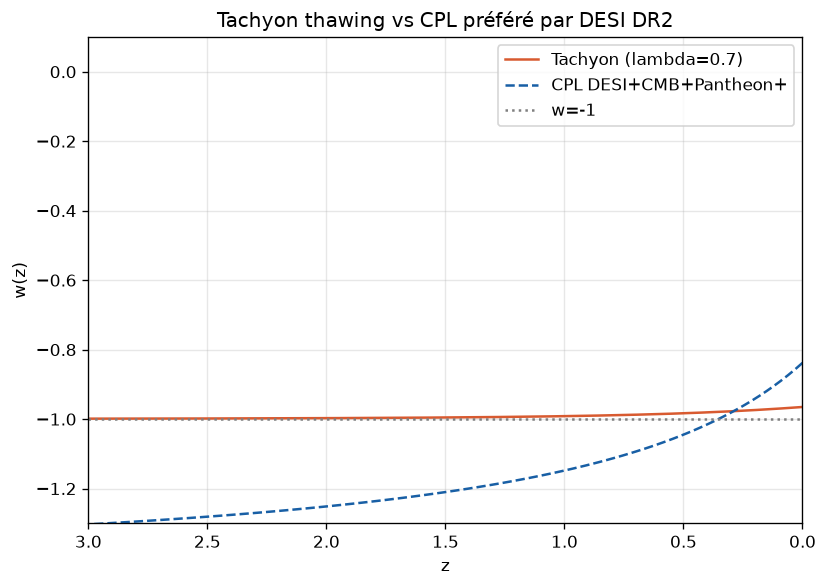

In [4]:
def w_cpl(z, w0, wa):
    return w0 + wa * z / (1 + z)

z_plot = np.linspace(0, 3, 100)
w0_desi, wa_desi = -0.838, -0.62  # DESI+CMB+Pantheon+, Table V

pot = ExponentialPotential(V0=1.0, lam=0.7)
bg = build_tachyon_background(pot, Omega_m, phi_init=0.0, x_init=0.0, z_init=50.0)

plt.figure(figsize=(7,5))
plt.plot(bg["z"], bg["w"], label="Tachyon (lambda=0.7)", color='#D85A30')
plt.plot(z_plot, w_cpl(z_plot, w0_desi, wa_desi), '--',
         label=f"CPL DESI+CMB+Pantheon+", color='#185FA5')
plt.axhline(-1, color='gray', ls=':', label='w=-1')
plt.xlim(0,3); plt.ylim(-1.3, 0.1)
plt.xlabel("z"); plt.ylabel("w(z)"); plt.gca().invert_xaxis()
plt.legend(); plt.title("Tachyon thawing vs CPL préféré par DESI DR2")
plt.tight_layout()
plt.savefig('../../results/figures/tachyon_vs_cpl.png', bbox_inches='tight')
plt.show()